In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

HI_DIR = "HI_figs"
ONE_SR_DIR = "One_s_r_figs"


# ============================================================
# SWITCHING-RULE LABELS
# ============================================================

RULE_LABELS = {
    "noswitch": "No switching",
    "S_to_R": r"$S \rightarrow R$",
    "R_to_S": r"$R \rightarrow S$",
    "S_R": r"$S \leftrightarrow R$",
    "threshold": "Drug-threshold",
    "uptake": "Drug-threshold + drug uptake",
    "independent": "Independent switching",
}


# ============================================================
# IDENTIFY SWITCHING RULE
# ============================================================

def identify_rule(dirname):

    name = dirname.lower()

    # Order matters — check more specific names first

    if "independent_switch" in name:
        return "independent"

    if "doubleswitch" in name or "double_switch" in name:
        return "S_R"

    if "drug_threshold" in name:
        return "threshold"

    if "uptake" in name:
        return "uptake"

    if "noswitch" in name:
        return "noswitch"

    if "rs_switch" in name or name.endswith("_rs"):
        return "R_to_S"

    if "sr_switch" in name or name.endswith("_sr"):
        return "S_to_R"

    # HI folder naming
    if "allbd_rs" in name:
        return "R_to_S"

    if "allbd_sr" in name:
        return "S_to_R"

    if "doubleswitch" in name:
        return "S_R"

    if "drug_threshold" in name:
        return "threshold"

    return None


# ============================================================
# READ tot_area.csv
# ============================================================

def read_tot_area(filepath):

    df = pd.read_csv(filepath)

    # First column = MCS
    # Second column = total cell area

    mcs = df.iloc[:, 0].values
    area = df.iloc[:, 1].values

    return mcs, area


# ============================================================
# COLLECT DATA
# ============================================================

def collect_data(base_dir):

    results = []

    for dirname in sorted(os.listdir(base_dir)):

        full_dir = os.path.join(base_dir, dirname)

        if not os.path.isdir(full_dir):
            continue

        rule = identify_rule(dirname)

        if rule is None:
            print(f"WARNING: Could not identify rule: {dirname}")
            continue

        filepath = os.path.join(full_dir, "tot_area.csv")

        if not os.path.isfile(filepath):
            print(f"WARNING: No tot_area.csv in {full_dir}")
            continue

        mcs, area = read_tot_area(filepath)

        results.append({
            "directory": dirname,
            "rule": rule,
            "rule_label": RULE_LABELS[rule],
            "mcs": mcs,
            "area": area
        })

    return results


HI_data = collect_data(HI_DIR)
ONE_data = collect_data(ONE_SR_DIR)


print(f"\nFound {len(HI_data)} HI simulations")
print(f"Found {len(ONE_data)} 1:15 simulations")

print("\nHI:")
for x in HI_data:
    print(" ", x["directory"], "→", x["rule_label"])

print("\n1:15:")
for x in ONE_data:
    print(" ", x["directory"], "→", x["rule_label"])


Found 14 HI simulations
Found 14 1:15 simulations

HI:
  High_HI_all_bd_drug_threshold → Drug-threshold
  High_HI_allbd_RS → $R \rightarrow S$
  High_HI_allbd_SR → $S \rightarrow R$
  High_HI_allbd_doubleswitch → $S \leftrightarrow R$
  High_HI_allbd_noswitch → No switching
  High_HI_topbd_uptake → Drug-threshold + drug uptake
  Low_HI_all_bd_drug_threshold → Drug-threshold
  Low_HI_allbd_RS → $R \rightarrow S$
  Low_HI_allbd_SR → $S \rightarrow R$
  Low_HI_allbd_noswitch → No switching
  Low_HI_allbd_uptake → Drug-threshold + drug uptake
  independent_switch_highHI → Independent switching
  independent_switch_lowHI → Independent switching
  low_HI_allbd_doubleswitch → $S \leftrightarrow R$

1:15:
  drug_c1c2_RS_switch_oner → $R \rightarrow S$
  drug_c1c2_RS_switch_ones → $R \rightarrow S$
  drug_c1c2_SR_switch_oner → $S \rightarrow R$
  drug_c1c2_SR_switch_ones → $S \rightarrow R$
  drug_c1c2_noswitch_oner → No switching
  drug_c1c2_noswitch_ones → No switching
  drug_double_switch_o

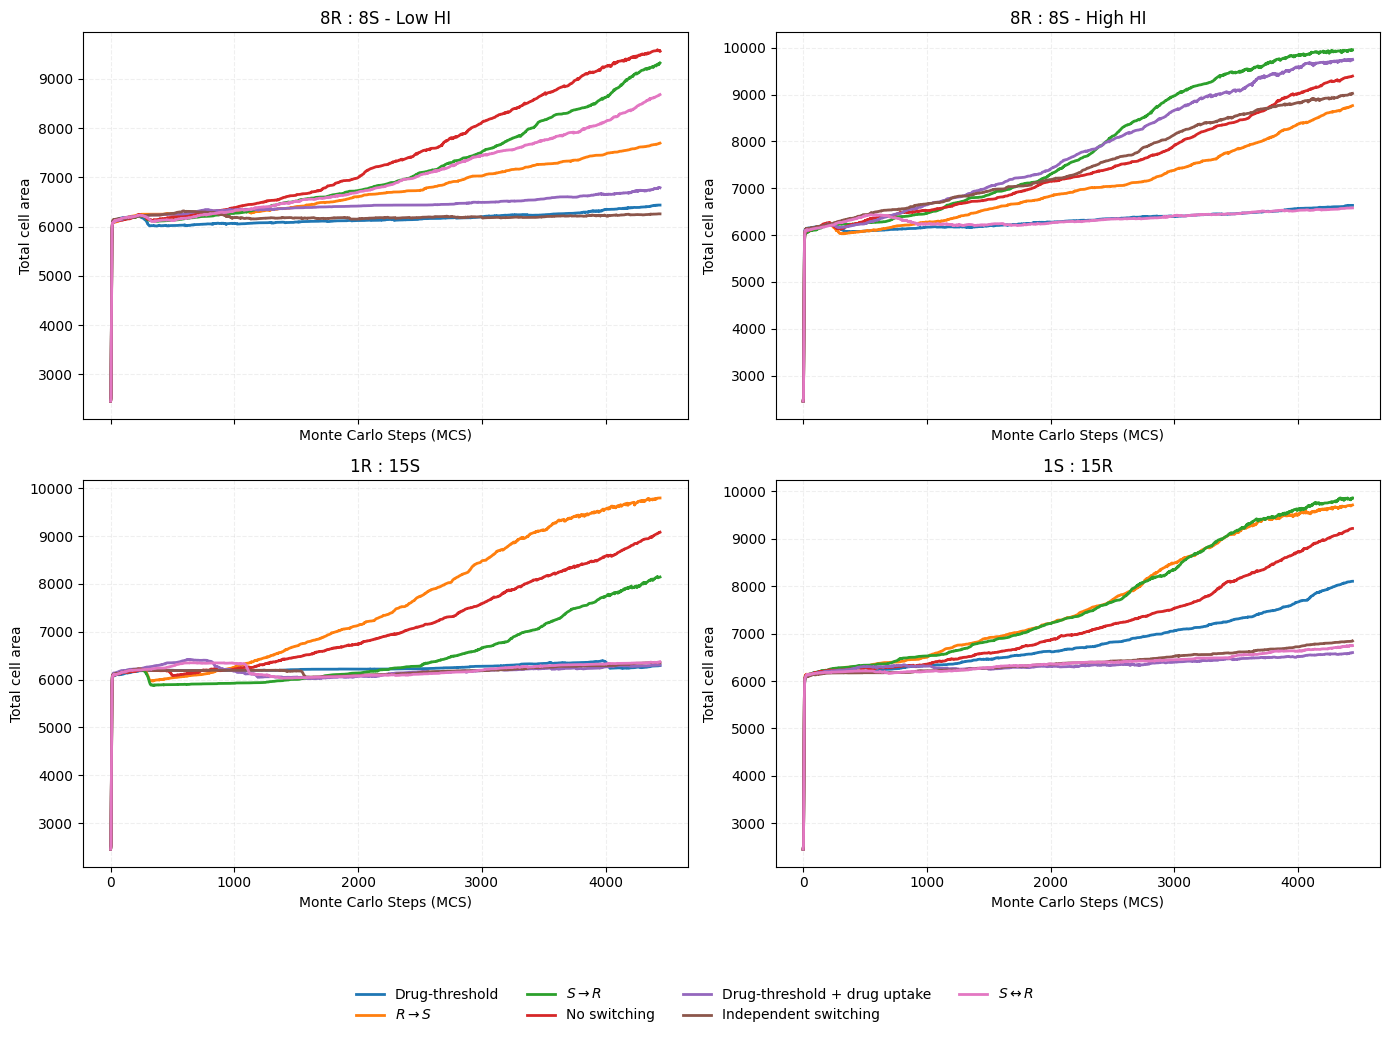

In [3]:
# ============================================================
# FOUR-PANEL TOTAL AREA FIGURE
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharex=True
)


# ------------------------------------------------------------
# PLOT HI DATA
# ------------------------------------------------------------

for result in HI_data:

    name = result["directory"].lower()

    # Low HI
    if "low_hi" in name or "lowhi" in name:
        ax = axes[0, 0]

    # High HI
    elif "high_hi" in name or "highhi" in name:
        ax = axes[0, 1]

    else:
        continue

    ax.plot(
        result["mcs"],
        result["area"],
        label=result["rule_label"],
        linewidth=2
    )


# ------------------------------------------------------------
# PLOT 1:15 DATA
# ------------------------------------------------------------

for result in ONE_data:

    name = result["directory"].lower()

    # 1R : 15S
    if name.endswith("_oner"):
        ax = axes[1, 0]

    # 1S : 15R
    elif name.endswith("_ones"):
        ax = axes[1, 1]

    else:
        continue

    ax.plot(
        result["mcs"],
        result["area"],
        label=result["rule_label"],
        linewidth=2
    )


# ------------------------------------------------------------
# FORMAT PANELS
# ------------------------------------------------------------

for ax in axes.flat:

    ax.set_xlabel("Monte Carlo Steps (MCS)")
    ax.set_ylabel("Total cell area")

    ax.grid(
        alpha=0.2,
        linestyle="--"
    )


axes[0, 0].set_title("8R : 8S - Low HI")
axes[0, 1].set_title("8R : 8S - High HI")
axes[1, 0].set_title("1R : 15S")
axes[1, 1].set_title("1S : 15R")


# ------------------------------------------------------------
# COLLECT LEGEND FROM ALL FOUR PANELS
# ------------------------------------------------------------

handles = []
labels = []

for ax in axes.flat:

    h, l = ax.get_legend_handles_labels()

    for handle, label in zip(h, l):

        if label not in labels:
            handles.append(handle)
            labels.append(label)


# ------------------------------------------------------------
# SINGLE LEGEND FOR ENTIRE FIGURE
# ------------------------------------------------------------

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,
    frameon=False
)


plt.tight_layout(
    rect=[0, 0.07, 1, 1]
)

plt.show()

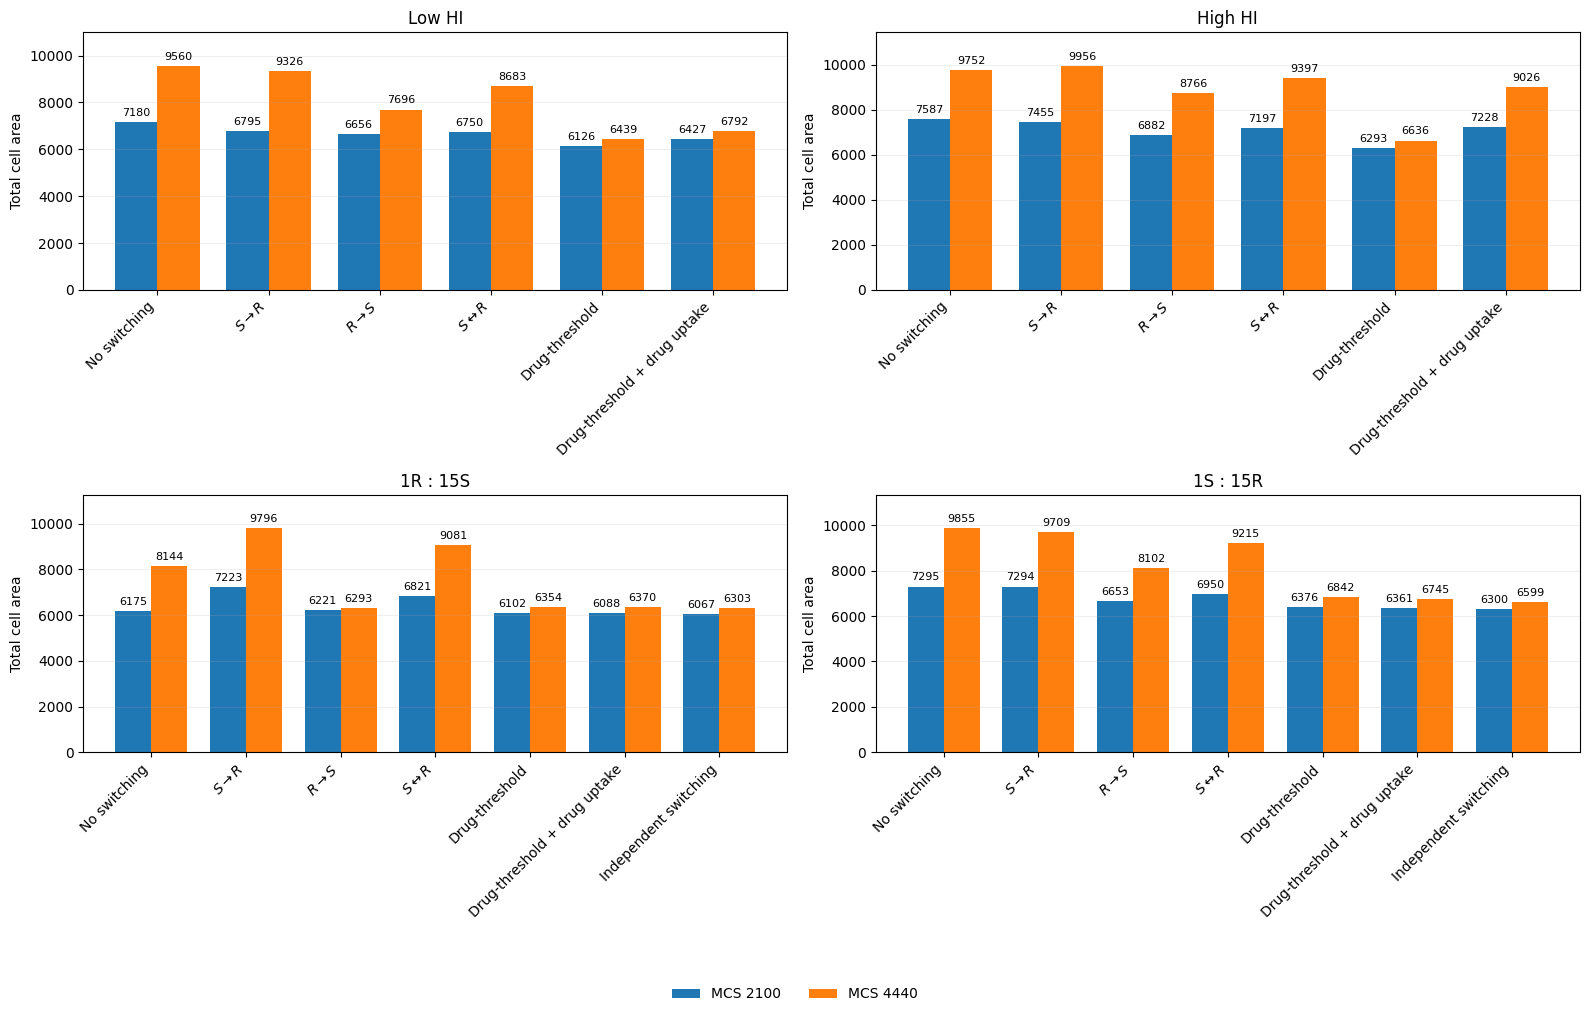

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def get_area_at_mcs(result, target_mcs):
    mcs = np.asarray(result["mcs"])
    area = np.asarray(result["area"])

    idx = np.argmin(np.abs(mcs - target_mcs))

    return area[idx], mcs[idx]


rule_order = [
    "noswitch",
    "S_to_R",
    "R_to_S",
    "S_R",
    "threshold",
    "uptake",
    "independent"
]


fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharey=False
)


conditions = [
    ("Low HI", axes[0, 0]),
    ("High HI", axes[0, 1]),
    ("1R : 15S", axes[1, 0]),
    ("1S : 15R", axes[1, 1])
]


for title, ax in conditions:

    # --------------------------------------------------------
    # SELECT DATA
    # --------------------------------------------------------

    if title == "Low HI":
        data = [
            r for r in HI_data
            if "low_hi" in r["directory"].lower()
        ]

    elif title == "High HI":
        data = [
            r for r in HI_data
            if "high_hi" in r["directory"].lower()
        ]

    elif title == "1R : 15S":
        data = [
            r for r in ONE_data
            if r["directory"].lower().endswith("_oner")
        ]

    elif title == "1S : 15R":
        data = [
            r for r in ONE_data
            if r["directory"].lower().endswith("_ones")
        ]

    # --------------------------------------------------------
    # SORT BY SWITCHING RULE
    # --------------------------------------------------------

    data = sorted(
        data,
        key=lambda r: rule_order.index(r["rule"])
    )

    labels = []
    area_2100 = []
    area_4440 = []

    for result in data:

        value_2100, actual_mcs = get_area_at_mcs(
            result, 2100
        )

        # Explicitly use MCS 4440
        value_4440, actual_final_mcs = get_area_at_mcs(
            result, 4440
        )

        labels.append(result["rule_label"])
        area_2100.append(value_2100)
        area_4440.append(value_4440)

    # --------------------------------------------------------
    # BAR POSITIONS
    # --------------------------------------------------------

    x = np.arange(len(labels))
    width = 0.38

    bars_2100 = ax.bar(
        x - width / 2,
        area_2100,
        width,
        label="MCS 2100"
    )

    bars_4440 = ax.bar(
        x + width / 2,
        area_4440,
        width,
        label="MCS 4440"
    )

    # --------------------------------------------------------
    # VALUE LABELS
    # --------------------------------------------------------

    ax.bar_label(
        bars_2100,
        labels=[f"{v:.0f}" for v in area_2100],
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        bars_4440,
        labels=[f"{v:.0f}" for v in area_4440],
        padding=3,
        fontsize=8
    )

    # --------------------------------------------------------
    # FORMAT
    # --------------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )

    ax.set_title(title)
    ax.set_ylabel("Total cell area")

    ax.grid(
        axis="y",
        alpha=0.2
    )

    # Give labels above bars some room
    ax.margins(y=0.15)


# ============================================================
# SINGLE LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=False
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

plt.show()